# 13 변수 중요도 분석

type(E·C)별 XGBoost **gain** 기반 feature importance로
lag·rolling·외생변수 기여도를 봅니다. (예측 Best를 고르는 장이 아님)

| 항목 | 내용 |
|------|------|
| 도구 | XGBoost `feature_importances_` (gain) |
| 단위 | type별 패널 학습 |
| 데이터 | `df_weekly_features.parquet` 학습 구간 |

선행: 02·03 | 다음: 14 Optuna


### ⓪ 환경 설정

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'code' else NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'code'))

from utils.paths import DATA_PROCESSED
from utils.splits import TRAIN_WEEK_MAX
from utils.device import device_label
from utils.feature_importance import (
    feature_cols, importance_by_type, importance_pivot,
)

print('Torch device:', device_label())
feat_df = pd.read_parquet(DATA_PROCESSED / 'df_weekly_features.parquet')
types = sorted(feat_df['type'].unique())
cols = feature_cols(feat_df)
print('types:', types)
print('피처 수:', len(cols), '| 학습 <=', TRAIN_WEEK_MAX)


Torch device: cuda (NVIDIA GeForce RTX 5090, 32GB)
types: ['C', 'E']
피처 수: 17 | 학습 <= 201707


### ① type별 XGBoost 학습 · 변수 중요도

각 type 내 모든 family 시계열을 **패널**로 합쳐 XGBoost 1개를 학습합니다 (08장 `forecast_ml_panel`과 동일 구조).

In [2]:
imp_long = importance_by_type(feat_df, types)
imp_pivot = importance_pivot(imp_long)

print('=== type별 Top 10 피처 ===')
for t in types:
    top = imp_long[imp_long['type'] == t].nlargest(10, 'importance_pct')
    print(f'\n--- Type {t} ---')
    print(top.to_string(index=False))

display(imp_pivot.round(2))


=== type별 Top 10 피처 ===

--- Type C ---
type       feature  importance_pct
   C         lag_1       68.901199
   C   roll_mean_4       19.349199
   C  roll_mean_12        6.538300
   C   roll_mean_8        1.971800
   C         lag_4        1.383300
   C         lag_2        0.403900
   C         lag_8        0.286900
   C  transactions        0.251900
   C    dcoilwtico        0.145200
   C zero_ratio_12        0.127000

--- Type E ---
type      feature  importance_pct
   E        lag_1       73.744202
   E        lag_2        8.027500
   E  roll_mean_8        7.188500
   E  roll_mean_4        6.760200
   E roll_mean_12        1.067100
   E        lag_4        0.627700
   E transactions        0.614100
   E        lag_8        0.547300
   E   is_holiday        0.229400
   E   dcoilwtico        0.188200


type,C,E
feature,,
dcoilwtico,0.15,0.19
is_holiday,0.06,0.23
lag_1,68.90,73.74
lag_2,0.40,8.03
lag_4,1.38,0.63
lag_8,0.29,0.55
month,0.11,0.14
onpromotion,0.12,0.18
roll_mean_12,6.54,1.07


### ② 시각화 — type별 Top 15 피처

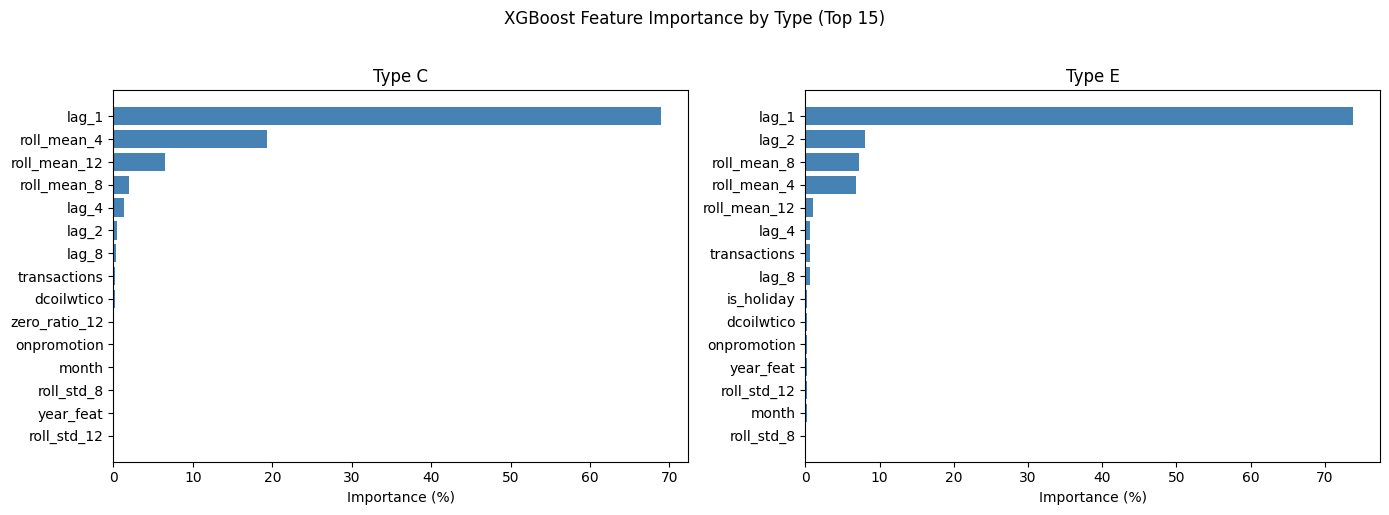

In [3]:
TOP_K = 15
n = len(types)
fig, axes = plt.subplots(1, n, figsize=(7*n, 5), squeeze=False)
axes = axes.flatten()
for i, t in enumerate(types):
    ax = axes[i]
    sub = imp_long[imp_long['type'] == t].nlargest(TOP_K, 'importance_pct')
    ax.barh(sub['feature'][::-1], sub['importance_pct'][::-1], color='steelblue')
    ax.set_title(f'Type {t}')
    ax.set_xlabel('Importance (%)')
fig.suptitle('XGBoost Feature Importance by Type (Top 15)', y=1.02)
plt.tight_layout()
plt.show()

### ③ type 간 공통·차별 피처

In [4]:
# type 평균 중요도
mean_imp = imp_pivot.mean(axis=1).sort_values(ascending=False)
print('=== 2 type 평균 Top 15 ===')
print(mean_imp.head(15).round(2))

# type 간 중요도 표준편차 — type마다 기여도가 다른 피처
std_imp = imp_pivot.std(axis=1).sort_values(ascending=False)
hetero = pd.DataFrame({
    'mean_pct': mean_imp,
    'std_across_types': std_imp,
}).sort_values('std_across_types', ascending=False)
print('\n=== type 간 중요도 편차 큰 피처 (차별적) ===')
print(hetero.head(10).round(2))


=== 2 type 평균 Top 15 ===
feature
lag_1           71.32
roll_mean_4     13.05
roll_mean_8      4.58
lag_2            4.22
roll_mean_12     3.80
lag_4            1.01
transactions     0.43
lag_8            0.42
dcoilwtico       0.17
onpromotion      0.15
is_holiday       0.14
year_feat        0.13
roll_std_12      0.13
month            0.13
roll_std_8       0.11
dtype: float64

=== type 간 중요도 편차 큰 피처 (차별적) ===
              mean_pct  std_across_types
feature                                 
roll_mean_4      13.05              8.90
lag_2             4.22              5.39
roll_mean_12      3.80              3.87
roll_mean_8       4.58              3.69
lag_1            71.32              3.42
lag_4             1.01              0.53
transactions      0.43              0.26
lag_8             0.42              0.18
is_holiday        0.14              0.12
roll_std_12       0.13              0.06


### 해석

- lag·roll_mean 상위 → 과거 판매 수준·추세가 핵심
- zero_ratio·ADI·CV² 상위 → 간헐 수요 특성
- oil·holiday·transactions 상위 → 외생·매장 활동
- type 간 순위가 다르면 드라이버가 type마다 다름

튜닝 전 고정 하이퍼파라미터 기준입니다.


In [5]:
out = DATA_PROCESSED
imp_long.to_csv(out / 'xgboost_feature_importance_by_type.csv', index=False)
imp_pivot.round(4).to_csv(out / 'xgboost_feature_importance_pivot.csv')
print('저장:', out / 'xgboost_feature_importance_by_type.csv')


저장: C:\Users\kjh\ai-retail-demandforecasting\data\processed\xgboost_feature_importance_by_type.csv
